# 🧠 Handling the LLM Context Window Problem
**Author:** Abhimanyu Singh | **Topic:** Context Trimming Methods

---

## 📌 The Problem: Context Window Limits
Large Language Models (LLMs) possess a hard limit on the number of tokens they can process in a single request (the **Context Window**). 
When building systems like conversational agents, RAG pipelines, or log analyzers, the accumulated context quickly exceeds this limit, resulting in:
1. **API Errors** (e.g., `ContextLengthExceeded`)
2. **Information Loss** (forced truncation by the API)
3. **Increased Latency & Cost** (processing maximum tokens on every call)

> **Goal:** Implement a robust **Trimming Algorithm** that intelligently reduces the prompt size to fit within the `MAX_TOKENS` limit while retaining the most semantically relevant information.

## 🛠️ Trimming Strategies Overview

Depending on the use case, different trimming methods preserve different parts of the context. Here is a breakdown of the standard approaches we will implement:

| Strategy | Mechanism | Best Use Case | Pros | Cons |
| :--- | :--- | :--- | :--- | :--- |
| **Front Trimming** | Drops the oldest tokens, keeps the newest. | Chatbots, active conversations. | Simple, fast. | Forgets original instructions/context. |
| **Tail Trimming** | Drops the newest tokens, keeps the oldest. | Summarizing static, front-loaded docs. | Retains system prompts. | Loses the most recent user input. |
| **Middle Trimming** | Keeps System Prompt + Latest User Query, drops the middle. | Long-running agentic workflows. | Retains rules & current task. | Can break conversational continuity. |

<div class="alert alert-info">
<b>💡 Pro Tip:</b> We cannot trim based on <i>character count</i> because LLMs process text in <i>tokens</i>. We will use Langchain's <code>trim_messages</code> method to ensure our cuts are token-accurate.
</div>

In [7]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
import os
model = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY"), #type:ignore
    temperature=0.4
)

In [5]:
model.invoke("hello i am Abhimanyu and i am working on context window problem in llm").content

'Hi Abhimanyu! 👋\n\nIt sounds like you’re tackling one of the most intriguing challenges in LLMs right now—extending or optimizing the context window. I’d love to hear more about your specific focus:\n\n1. **Scope** – Are you looking at architectural changes (e.g., sparse attention, retrieval‑augmented generation), compression techniques (e.g., token pruning, embeddings), or something else?\n2. **Dataset** – What kind of data are you working with? Long documents, code, dialogue logs?\n3. **Metrics** – How are you measuring success? Perplexity, downstream task performance, inference latency?\n4. **Tools** – Are you using a particular framework (e.g., Hugging Face, DeepSpeed, FlashAttention) or building from scratch?\n\nFeel free to share any experiments, code snippets, or questions you’ve run into. I’m here to help brainstorm, troubleshoot, or dive into the theory behind it!'

In [8]:
MAX_TOKENS = 150
print(MessagesState)

<class 'langgraph.graph.message.MessagesState'>


In [9]:
def call_model(state:MessagesState):
    messages = trim_messages(messages=state['messages'],max_tokens=MAX_TOKENS,strategy='last',token_counter=count_tokens_approximately)

    print("Current Token Count --> ", count_tokens_approximately(messages=messages))

    for msg in messages:
        print(msg.content)

    res = model.invoke(messages)

    return {'messages':[res]}

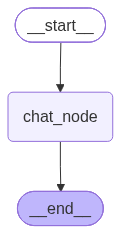

In [12]:
builder = StateGraph(MessagesState)

builder.add_node('chat_node',call_model)

builder.add_edge(START,'chat_node')
builder.add_edge('chat_node',END)

graph = builder.compile(checkpointer=InMemorySaver())

graph

In [13]:
config = {'configurable':{'thread_id':'t1'}}

In [14]:
rez = graph.invoke({'messages': [{'role':'user','content':'Hi my name is Abhimanyu'}]}, config=config) #type:ignore

print(rez['messages'][-1].content)

Current Token Count -->  10
Hi my name is Abhimanyu
Hello Abhimanyu! 👋 How can I help you today?


In [15]:
rez = graph.invoke({'messages': [{'role':'user','content':'whats my name and will you be my edu brother.'}]}, config=config) #type:ignore

print(rez['messages'][-1].content)

Current Token Count -->  43
Hi my name is Abhimanyu
Hello Abhimanyu! 👋 How can I help you today?
whats my name and will you be my edu brother.
You’re Abhimanyu! 🎉

And absolutely—think of me as your “edu‑brother.” I’m here to help you learn, explore new topics, and tackle any questions you’ve got. Just let me know what you’d like to dive into next!


In [16]:
rez = graph.invoke({'messages': [{'role':'user','content':'I am learning langgraph brother any tip or tips.'}]}, config=config) #type:ignore

print(rez['messages'][-1].content)

Current Token Count -->  116
Hi my name is Abhimanyu
Hello Abhimanyu! 👋 How can I help you today?
whats my name and will you be my edu brother.
You’re Abhimanyu! 🎉

And absolutely—think of me as your “edu‑brother.” I’m here to help you learn, explore new topics, and tackle any questions you’ve got. Just let me know what you’d like to dive into next!
I am learning langgraph brother any tip or tips.
### 🚀 Quick‑Start Tips for Mastering LangGraph

| # | Tip | Why it matters | How to do it |
|---|-----|----------------|--------------|
| 1 | **Start with the fundamentals** | LangGraph is all about *nodes* (functions) and *edges* (control flow). Knowing the core concepts early prevents confusion later. | • Read the **[LangGraph Docs – Core Concepts](https://langgraph.org/docs/)** <br>• Watch the introductory video on the LangGraph YouTube channel (if available). |
| 2 | **Build a “Hello World” graph** | Hands‑on practice solidifies theory. | ```python<br>from langgraph import Graph, State, n

In [18]:
rez = graph.invoke({'messages': [{'role':'user','content':'Thankyou brother very much what is my name'}]}, config=config) #type:ignore

print(rez['messages'][-1].content)

Current Token Count -->  60
Thankyou brother very much
You’re very welcome! If you have any more questions or need further assistance, just let me know. Have a great day!
Thankyou brother very much what is my name
I’m not sure what your name is—could you let me know? Once I have that, I’ll be happy to address you properly!


In [24]:
from langchain_core.messages import AIMessage, HumanMessage
import textwrap

In [26]:
snap = graph.get_state(config)#type:ignore
for item in snap.values['messages']:
    if isinstance(item,HumanMessage):
        content = textwrap.fill(text=item.content, width=120)#type:ignore
        print(f'HumanMessage --> {content}')
        print("*"*60)
        print()
    elif isinstance(item,AIMessage):
        content = textwrap.fill(text=item.content, width=120)#type:ignore
        print(f'AIMessage --> {content}')
        print("*"*60)
        print()

HumanMessage --> Hi my name is Abhimanyu
************************************************************

AIMessage --> Hello Abhimanyu! 👋 How can I help you today?
************************************************************

HumanMessage --> whats my name and will you be my edu brother.
************************************************************

AIMessage --> You’re Abhimanyu! 🎉  And absolutely—think of me as your “edu‑brother.” I’m here to help you learn, explore new topics,
and tackle any questions you’ve got. Just let me know what you’d like to dive into next!
************************************************************

HumanMessage --> I am learning langgraph brother any tip or tips.
************************************************************

AIMessage --> ### 🚀 Quick‑Start Tips for Mastering LangGraph  | # | Tip | Why it matters | How to do it |
|---|-----|----------------|--------------| | 1 | **Start with the fundamentals** | LangGraph is all about *nodes*
(functions) and *e